In [1]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv('../data/superstore_cleaned.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
for col in ['Sales', 'Profit', 'Discount', 'Quantity']:
    print(f"--- {col} ---")
    print(f"Mean: {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    print(f"Mode: {df[col].mode()[0]:.2f}")
    print(f"Std Dev: {df[col].std():.2f}")
    print(f"Skewness: {df[col].skew():.2f}")
    print()

--- Sales ---
Mean: 229.86
Median: 54.49
Mode: 12.96
Std Dev: 623.25
Skewness: 12.97

--- Profit ---
Mean: 28.66
Median: 8.67
Mode: 0.00
Std Dev: 234.26
Skewness: 7.56

--- Discount ---
Mean: 0.16
Median: 0.20
Mode: 0.00
Std Dev: 0.21
Skewness: 1.68

--- Quantity ---
Mean: 3.79
Median: 3.00
Mode: 3.00
Std Dev: 2.23
Skewness: 1.28



In [3]:
high_discount = df[df['Discount'] > 0.2]['Profit']
low_discount = df[df['Discount'] <= 0.2]['Profit']

t_stat, p_value = stats.ttest_ind(high_discount, low_discount)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("Statistically significant difference in profit between high vs low discount orders.")
else:
    print("No statistically significant difference.")

T-statistic: -22.1342
P-value: 0.000000
Statistically significant difference in profit between high vs low discount orders.


In [4]:
contingency = pd.crosstab(df['Region'], df['Category'])
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p:.6f}")

if p < 0.05:
    print("Significant relationship between Region and Category.")
else:
    print("No significant relationship.")

Chi-square statistic: 3.6619
P-value: 0.722316
No significant relationship.


In [5]:
mean_profit = df['Profit'].mean()
sem = stats.sem(df['Profit'])
ci = stats.t.interval(0.95, len(df['Profit'])-1, loc=mean_profit, scale=sem)
print(f"Mean Profit: {mean_profit:.2f}")
print(f"95% Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f})")

Mean Profit: 28.66
95% Confidence Interval: (24.06, 33.25)


In [6]:
df['Order_Date'] = pd.to_datetime(df['Order Date'] if 'Order Date' in df.columns else df['Order_Date'])
ts = df.set_index('Order_Date')['Sales']
ts.head()

Order_Date
2016-11-08    261.9600
2016-11-08    731.9400
2016-06-12     14.6200
2015-10-11    957.5775
2015-10-11     22.3680
Name: Sales, dtype: float64

<AxesSubplot:title={'center':'Monthly Sales Over Time'}, xlabel='Order_Date'>

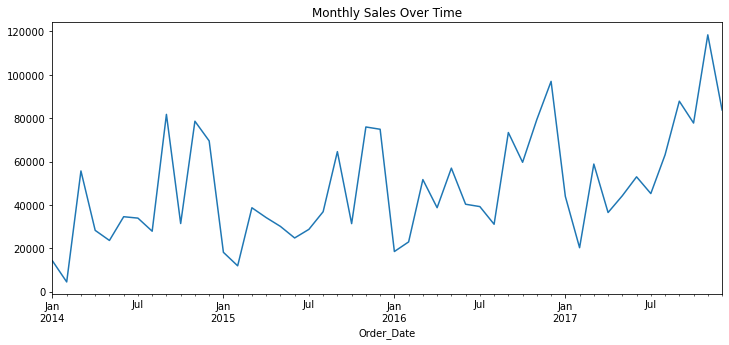

In [7]:
monthly_sales = ts.resample('M').sum()
monthly_sales.plot(figsize=(12,5), title='Monthly Sales Over Time')

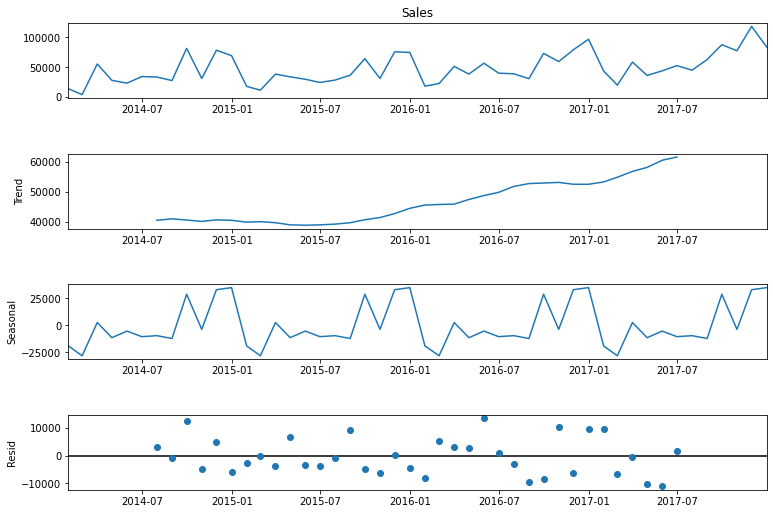

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(monthly_sales, model='additive', period=12)

fig = decomposition.plot()
fig.set_size_inches(12, 8)

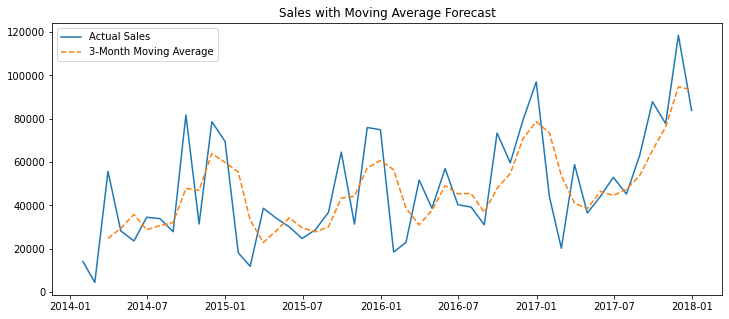

In [9]:
monthly_sales_ma = monthly_sales.rolling(window=3).mean()

import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(monthly_sales, label='Actual Sales')
plt.plot(monthly_sales_ma, label='3-Month Moving Average', linestyle='--')
plt.legend()
plt.title('Sales with Moving Average Forecast')
plt.show()

In [10]:
customer_features = df.groupby('Customer_ID' if 'Customer_ID' in df.columns else 'Customer ID').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Order_Count=('Order_ID' if 'Order_ID' in df.columns else 'Order ID', 'nunique'),
    Avg_Discount=('Discount', 'mean')
).reset_index()

customer_features.head()

,Customer ID,Total_Sales,Total_Profit,Order_Count,Avg_Discount
0,AA-10315,5563.560,-362.8825,5,0.090909
1,AA-10375,1056.390,277.3824,9,0.080000
2,AA-10480,1790.512,435.8274,4,0.016667
3,AA-10645,5086.935,857.8033,6,0.063889
4,AB-10015,886.156,129.3465,3,0.066667


In [11]:
from sklearn.preprocessing import StandardScaler

features = customer_features[['Total_Sales', 'Total_Profit', 'Order_Count', 'Avg_Discount']]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

C:\Users\Jaya\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:881: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


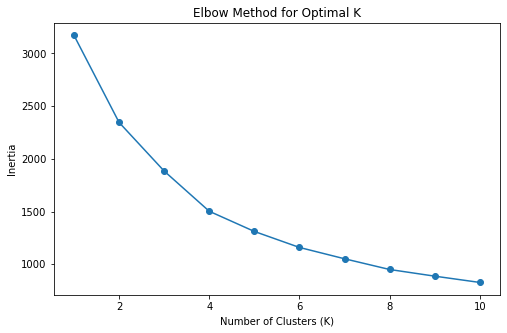

In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.show()

In [13]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_features['Cluster'] = kmeans.fit_predict(scaled_features)
customer_features.head()

,Customer ID,Total_Sales,Total_Profit,Order_Count,Avg_Discount,Cluster
0,AA-10315,5563.560,-362.8825,5,0.090909,0
1,AA-10375,1056.390,277.3824,9,0.080000,1
2,AA-10480,1790.512,435.8274,4,0.016667,0
3,AA-10645,5086.935,857.8033,6,0.063889,0
4,AB-10015,886.156,129.3465,3,0.066667,0


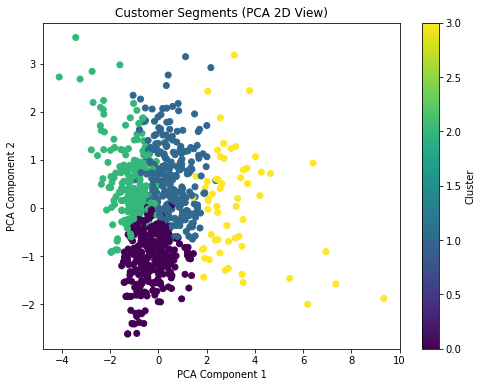

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

plt.figure(figsize=(8,6))
scatter = plt.scatter(pca_features[:,0], pca_features[:,1], c=customer_features['Cluster'], cmap='viridis')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Customer Segments (PCA 2D View)')
plt.colorbar(scatter, label='Cluster')
plt.show()

In [ ]:
cluster_profile = customer_features.groupby('Cluster')[['Total_Sales','Total_Profit','Order_Count','Avg_Discount']].mean()
cluster_profile

## Customer Segmentation Summary (K-Means Clustering, K=4)

| Cluster | Label | Total Sales (avg) | Total Profit (avg) | Order Count (avg) | Avg Discount | Recommendation |
|---|---|---|---|---|---|---|
| 3 | VIP / Top Customers | $9,321.85 | $2,229.42 | 8.29 | 11.6% | Prioritize retention — loyalty perks, dedicated support |
| 1 | Loyal Frequent Buyers | $3,564.49 | $330.49 | 8.74 | 16.2% | Shift toward bundles instead of discounts to protect margin |
| 0 | Low-Engagement / Occasional Buyers | $1,797.63 | $327.06 | 4.70 | 8.7% | Re-engagement campaigns to boost order frequency |
| 2 | Discount-Sensitive / Unprofitable | $1,616.59 | -$95.01 | 4.74 | 25.6% | Flag for discount policy review — currently losing money on average |

**Key takeaway:** Customers were segmented into 4 groups using K-Means clustering on scaled RFM-style features (total sales, total profit, order count, average discount). One segment (Cluster 2) is unprofitable on average, driven by a discount rate more than 2x higher than the VIP segment — consistent with the discount-driven profit erosion also seen at the product level (Tables/Bookcases) in Task 1.

In [16]:
from sklearn.model_selection import train_test_split

# Target: Profit
# Features: numeric + encoded categorical columns
model_df = df[['Sales', 'Quantity', 'Discount', 'Category', 'Sub_Category' if 'Sub_Category' in df.columns else 'Sub-Category', 'Region', 'Profit']].copy()

# One-hot encode categoricals
model_df = pd.get_dummies(model_df, columns=['Category', 'Sub_Category' if 'Sub_Category' in df.columns else 'Sub-Category', 'Region'], drop_first=True)

model_df.head()

,Sales,Quantity,Discount,Profit,Category_Office Supplies,Category_Technology,Sub-Category_Appliances,Sub-Category_Art,Sub-Category_Binders,Sub-Category_Bookcases,...,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables,Region_East,Region_South,Region_West
0,261.9600,2,0.00,41.9136,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
1,731.9400,3,0.00,219.5820,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,14.6200,2,0.00,6.8714,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
3,957.5775,5,0.45,-383.0310,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
4,22.3680,2,0.20,2.5164,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0


In [17]:
X = model_df.drop('Profit', axis=1)
y = model_df['Profit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(7995, 24) (1999, 24)


In [18]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [22]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

R²: -0.6439
MAE: 67.6843
RMSE: 282.3195


In [20]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

coef_df.head(3)

,Feature,Coefficient
10,Sub-Category_Copiers,271.811709
2,Discount,-237.147371
15,Sub-Category_Machines,-192.043293


In [21]:
# Remove rows where Profit is beyond 3 standard deviations
profit_mean, profit_std = df['Profit'].mean(), df['Profit'].std()
df_filtered = df[(df['Profit'] > profit_mean - 3*profit_std) & (df['Profit'] < profit_mean + 3*profit_std)]

print(f"Removed {len(df) - len(df_filtered)} outlier rows")

Removed 107 outlier rows


In [23]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R²: {r2:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

R²: -0.6439
MAE: 67.6843
RMSE: 282.3195


## Predictive Model: Profit Prediction (Linear Regression)

- **R²:** -0.64
- **MAE:** $67.68
- **RMSE:** $282.32

**Top 3 influential features:**
1. Sub-Category: Copiers (+271.81) — strongest positive driver of profit
2. Discount (-237.15) — strongest negative driver; each 1-unit increase in discount reduces predicted profit by ~$237
3. Sub-Category: Machines (-192.04) — associated with lower profit

**Interpretation:** The negative R² indicates the model performs worse than a naive baseline (predicting the average profit for every order). This is likely driven by extreme outlier orders (e.g., high-discount orders with losses exceeding -$1,800), which violate Linear Regression's sensitivity to outliers. Despite the weak overall fit, the model's coefficients still surface a consistent and business-relevant signal: **discounting is the single strongest lever reducing profit**, reinforcing findings from the EDA (Task 1) and clustering (Task 4) analyses. A more robust approach — such as removing outliers, using regularized regression (Ridge/Lasso), or predicting profit *margin* instead of raw profit — would likely improve predictive performance.